### Student Score Analyzer   

📌 Project Overview

This project analyzes student academic performance using Python.
The dataset contains intentional inconsistencies such as missing values, extra spaces, inconsistent text formatting, and outliers to simulate real-world data challenges.

The goal is to clean, process, and analyze the data to extract meaningful insights about student performance.

In [64]:
### importing pandas and loading file
import pandas as pd
student_score = pd.read_excel('student_scores.xlsx')

In [65]:
## viewing data to see how it looks like
student_score.head()

,Student_ID,Name,Gender,Math,English,Science,ICT
0,1,EFUA ASANTE,F,85.0,72.0,82.0,92.0
1,2,efua boateng,M,87.0,90.0,76.0,61.0
2,3,efua owusu,F,86.0,47.0,67.0,78.0
3,4,nana mensah,F,82.0,52.0,77.0,95.0
4,5,AKUA APPIAH,M,53.0,43.0,65.0,54.0


In [66]:
## Making a cop of this file before I start editing
data_backup = student_score.copy()

In [67]:
student_score.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Student_ID  200 non-null    int64  
 1   Name        200 non-null    object 
 2   Gender      200 non-null    object 
 3   Math        187 non-null    float64
 4   English     191 non-null    float64
 5   Science     183 non-null    float64
 6   ICT         190 non-null    float64
dtypes: float64(4), int64(1), object(2)
memory usage: 11.1+ KB


In [68]:
## statistical view of the data
student_score.describe()

,Student_ID,Math,English,Science,ICT
count,200.000000,187.000000,191.000000,183.000000,190.000000
mean,100.500000,67.090909,68.397906,69.180328,66.736842
std,57.879185,17.409899,16.093111,15.421380,15.827583
min,1.000000,40.000000,40.000000,40.000000,40.000000
25%,50.750000,52.000000,55.000000,57.000000,53.000000
50%,100.500000,66.000000,69.000000,71.000000,66.000000
75%,150.250000,81.500000,82.500000,81.000000,79.750000
max,200.000000,150.000000,95.000000,95.000000,95.000000


In [69]:
## Removing all empty spaces before colunm names
student_score.columns = student_score.columns.str.strip()
student_score.columns

Index(['Student_ID', 'Name', 'Gender', 'Math', 'English', 'Science', 'ICT'], dtype='object')

In [70]:
# Removing all empty spaces before name strings of colunm 'Name'
student_score['Name'] = student_score['Name'].str.strip()
student_score['Name'].head()

0     EFUA ASANTE
1    efua boateng
2      efua owusu
3     nana mensah
4     AKUA APPIAH
Name: Name, dtype: object

In [71]:
## Correction name letter organization: Capiatal letter before every name.

student_score['Name'] = student_score['Name'].str.strip().str.title()
student_score['Name']

0       Efua Asante
1      Efua Boateng
2        Efua Owusu
3       Nana Mensah
4       Akua Appiah
           ...     
195      Yaw Asante
196     Kwame Darko
197        Kojo Adu
198         Yaw Adu
199       Yaw Gyasi
Name: Name, Length: 200, dtype: object

In [72]:
## changeing all number figures to numbers in case some were entered a strings

subjects = ['Math', 'English', 'Science', 'ICT']

for subject in subjects:
    student_score[subject] = pd.to_numeric(student_score[subject], errors='coerce')
    student_score[subject]
print(student_score[subject])

0      92.0
1      61.0
2      78.0
3      95.0
4      54.0
       ... 
195    58.0
196    47.0
197    73.0
198    60.0
199    49.0
Name: ICT, Length: 200, dtype: float64


In [ ]:
## Finding outliers and replacing with a null value so it can be updated with the average of student average score

import numpy as np
student_score[subjects] = student_score[subjects].where(
    student_score[subjects] <= 100,
    np.nan
)

In [74]:
## Checking number of null values in the data
student_score.isnull().sum()

Student_ID     0
Name           0
Gender         0
Math          14
English        9
Science       17
ICT           10
dtype: int64

In [75]:
### Filling the null values with average of scores of individual
subjects = ['Math', 'English', 'Science', 'ICT']
student_score[subjects] = student_score[subjects].apply(
lambda row: row.fillna(row.mean()),axis = 1
)
student_score.isnull().sum()

Student_ID    0
Name          0
Gender        0
Math          0
English       0
Science       0
ICT           0
dtype: int64

In [76]:
## Finding outliers in the scores( If a score is greater than 100)
student_score[subjects].max()

Math       95.0
English    95.0
Science    95.0
ICT        95.0
dtype: float64

In [79]:
## Finding total of each student score
student_score['Total'] = student_score[subjects].sum(axis =1)
student_score.head(20)

,Student_ID,Name,Gender,Math,English,Science,ICT,Total
0,1,Efua Asante,F,85.000000,72.0,82.000000,92.0,331.000000
1,2,Efua Boateng,M,87.000000,90.0,76.000000,61.0,314.000000
2,3,Efua Owusu,F,86.000000,47.0,67.000000,78.0,278.000000
3,4,Nana Mensah,F,82.000000,52.0,77.000000,95.0,306.000000
4,5,Akua Appiah,M,53.000000,43.0,65.000000,54.0,215.000000
5,6,Abena Gyasi,F,55.000000,94.0,76.000000,62.0,287.000000
6,7,Yaw Gyasi,M,92.000000,84.0,92.000000,71.0,339.000000
7,8,Yaw Gyasi,M,49.000000,83.0,64.666667,62.0,258.666667
8,9,Abena Asante,M,64.666667,63.0,83.000000,48.0,258.666667
9,10,Efua Darko,M,62.000000,42.0,48.000000,52.0,204.000000


In [80]:
## Creating average of each student score
student_score['Average'] = student_score[subjects].mean(axis=1)
student_score

,Student_ID,Name,Gender,Math,English,Science,ICT,Total,Average
0,1,Efua Asante,F,85.0,72.0,82.0,92.0,331.0,82.75
1,2,Efua Boateng,M,87.0,90.0,76.0,61.0,314.0,78.50
2,3,Efua Owusu,F,86.0,47.0,67.0,78.0,278.0,69.50
3,4,Nana Mensah,F,82.0,52.0,77.0,95.0,306.0,76.50
4,5,Akua Appiah,M,53.0,43.0,65.0,54.0,215.0,53.75
...,...,...,...,...,...,...,...,...,...
195,196,Yaw Asante,M,55.0,76.0,67.0,58.0,256.0,64.00
196,197,Kwame Darko,M,42.0,76.0,61.0,47.0,226.0,56.50
197,198,Kojo Adu,F,87.0,92.0,63.0,73.0,315.0,78.75
198,199,Yaw Adu,M,54.0,89.0,54.0,60.0,257.0,64.25


In [81]:
student_score['Rank'] = student_score['Total'].rank(ascending=False, method='min')
student_score

,Student_ID,Name,Gender,Math,English,Science,ICT,Total,Average,Rank
0,1,Efua Asante,F,85.0,72.0,82.0,92.0,331.0,82.75,10.0
1,2,Efua Boateng,M,87.0,90.0,76.0,61.0,314.0,78.50,27.0
2,3,Efua Owusu,F,86.0,47.0,67.0,78.0,278.0,69.50,77.0
3,4,Nana Mensah,F,82.0,52.0,77.0,95.0,306.0,76.50,34.0
4,5,Akua Appiah,M,53.0,43.0,65.0,54.0,215.0,53.75,195.0
...,...,...,...,...,...,...,...,...,...,...
195,196,Yaw Asante,M,55.0,76.0,67.0,58.0,256.0,64.00,125.0
196,197,Kwame Darko,M,42.0,76.0,61.0,47.0,226.0,56.50,182.0
197,198,Kojo Adu,F,87.0,92.0,63.0,73.0,315.0,78.75,24.0
198,199,Yaw Adu,M,54.0,89.0,54.0,60.0,257.0,64.25,123.0


In [82]:
top_10 = student_score.sort_values('Rank', ascending= True).head(10)
top_10

,Student_ID,Name,Gender,Math,English,Science,ICT,Total,Average,Rank
64,65,Yaw Boateng,M,81.0,89.0,95.000000,95.0,360.000000,90.000000,1.0
144,145,Kwame Owusu,M,86.0,91.0,94.000000,89.0,360.000000,90.000000,1.0
181,182,Nana Darko,M,88.0,89.0,85.666667,80.0,342.666667,85.666667,3.0
125,126,Kojo Darko,M,93.0,78.0,78.000000,91.0,340.000000,85.000000,4.0
6,7,Yaw Gyasi,M,92.0,84.0,92.000000,71.0,339.000000,84.750000,5.0
74,75,Kofi Gyasi,M,94.0,72.0,92.000000,81.0,339.000000,84.750000,5.0
118,119,Abena Gyasi,M,92.0,69.0,84.333333,92.0,337.333333,84.333333,7.0
90,91,Kofi Appiah,F,94.0,84.0,72.000000,86.0,336.000000,84.000000,8.0
171,172,Efua Gyasi,M,63.0,88.0,92.000000,90.0,333.000000,83.250000,9.0
0,1,Efua Asante,F,85.0,72.0,82.000000,92.0,331.000000,82.750000,10.0


In [83]:
## Filtering the last 10 performing students
Last_10= student_score.sort_values('Rank', ascending=False).head(10)
Last_10

,Student_ID,Name,Gender,Math,English,Science,ICT,Total,Average,Rank
32,33,Efua Owusu,M,48.0,49.0,55.000000,40.0,192.000000,48.000000,200.0
9,10,Efua Darko,M,62.0,42.0,48.000000,52.0,204.000000,51.000000,198.0
111,112,Yaw Mensah,F,61.0,42.0,50.000000,51.0,204.000000,51.000000,198.0
199,200,Yaw Gyasi,M,47.0,57.0,55.000000,49.0,208.000000,52.000000,197.0
81,82,Yaw Adu,F,40.0,69.0,53.000000,50.0,212.000000,53.000000,196.0
4,5,Akua Appiah,M,53.0,43.0,65.000000,54.0,215.000000,53.750000,195.0
191,192,Kofi Owusu,M,71.0,49.0,45.000000,51.0,216.000000,54.000000,194.0
103,104,Ama Owusu,M,72.0,47.0,54.000000,44.0,217.000000,54.250000,193.0
107,108,Yaw Appiah,F,63.0,54.0,54.666667,47.0,218.666667,54.666667,192.0
157,158,Abena Mensah,M,62.0,52.0,55.000000,51.0,220.000000,55.000000,191.0


In [90]:
## ADD POSITION LABELS

def performance_label(rank):
    if rank <= 5:
        return 'Top Performer'
    elif rank <= 20:
        return 'Above Average'
    elif rank <= 50:
        return 'Average'
    else:
        return 'Needs Improvement'

student_score['Performance'] = student_score['Rank'].apply(performance_label)

In [84]:
## Gender based Analysis
student_score.groupby(['Gender'])[subjects].mean()

,Math,English,Science,ICT
Gender,,,,
F,66.959302,67.600775,67.013566,67.674419
M,66.356725,68.944444,70.644737,66.062865


In [93]:
## hardest subject and lowest subject
subject_avg = student_score[subjects].mean()
subject_avg.sort_values()

Math       66.615833
ICT        66.755833
English    68.366667
Science    69.083333
dtype: float64

### A Bar Chart showing the visual of average subject scores

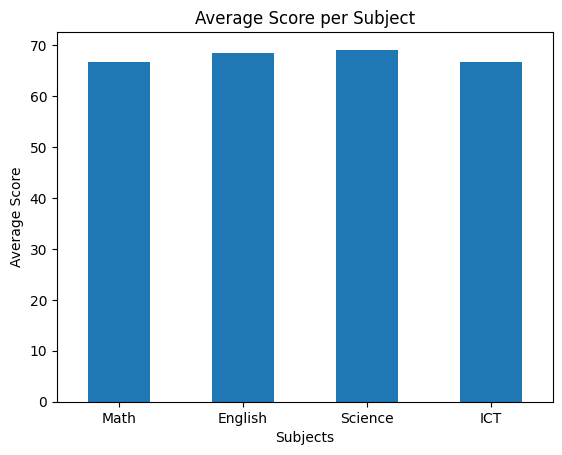

In [102]:
import matplotlib.pyplot as plt
subject_avg.plot(kind='bar')

plt.title("Average Score per Subject")
plt.xlabel("Subjects")
plt.ylabel("Average Score")
plt.xticks(rotation=0)

plt.show()

In [103]:
### correlation between subjects
student_score[subjects].corr()

,Math,English,Science,ICT
Math,1.000000,0.083325,0.191469,0.014186
English,0.083325,1.000000,0.066417,-0.063892
Science,0.191469,0.066417,1.000000,0.100316
ICT,0.014186,-0.063892,0.100316,1.000000


In [104]:
## Which students are consistent across subjects?

student_score['Std_Dev'] = student_score[subjects].std(axis=1)

most_consistent = student_score.nsmallest(5, 'Std_Dev')
print(most_consistent[['Name', 'Std_Dev', 'Rank']])

            Name   Std_Dev   Rank
52    Akua Darko  0.816497   28.0
47   Efua Appiah  0.957427  188.0
29   Kofi Asante  2.357023   83.0
130   Yaw Mensah  2.624669  154.0
86    Ama Asante  2.867442  140.0


In [105]:
## Finding best studnts in each subject

for subject in subjects:
    top = student_score.loc[student_score[subject].idxmax()]
    print(f"{subject}: {top['Name']} ({top[subject]})")

Math: Yaw Darko (95.0)
English: Ama Asante (95.0)
Science: Yaw Boateng (95.0)
ICT: Nana Mensah (95.0)


In [106]:
## checking for failure rate
for subject in subjects:
    fail_count = (student_score[subject] < 50).sum()
    print(f"{subject} failures: {fail_count}")

Math failures: 36
English failures: 33
Science failures: 24
ICT failures: 32


In [107]:
## overall perfomance of students

student_score['Performance'].value_counts()


Performance
Needs Improvement    150
Average               30
Above Average         14
Top Performer          6
Name: count, dtype: int64

### Showing PERFORMANCE DISTRIBUTION (PIE CHART) of the overall student peformance   

A large proportion of students fall under “Needs Improvement,” indicating overall low performance.

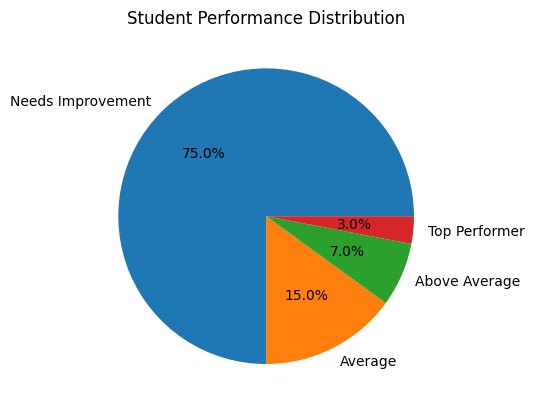

In [108]:
student_score['Performance'].value_counts().plot(kind='pie', autopct='%1.1f%%')

plt.title("Student Performance Distribution")
plt.ylabel("")

plt.show()

### SCORE DISTRIBUTION (HISTOGRAM)   

Most students cluster around mid-range scores, with fewer high-performing students

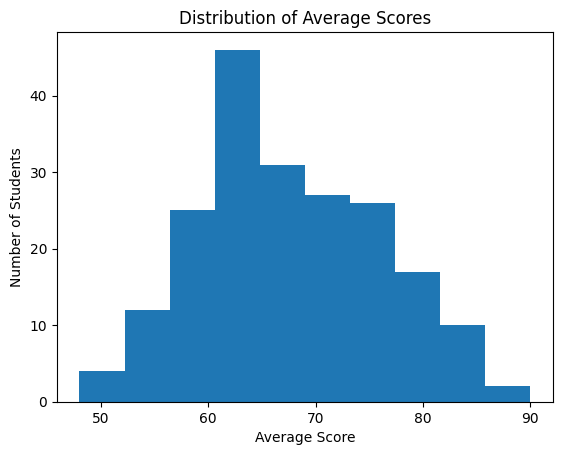

In [110]:
student_score['Average'].plot(kind='hist', bins=10)

plt.title("Distribution of Average Scores")
plt.xlabel("Average Score")
plt.ylabel("Number of Students")

plt.show()

### GENDER PERFORMANCE (BAR CHART)
Performance differences between genders are relatively small across subjects.

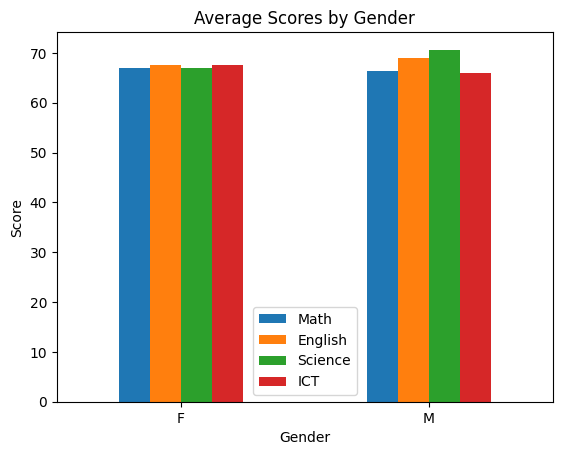

In [111]:
gender_avg = student_score.groupby('Gender')[subjects].mean()

gender_avg.plot(kind='bar')

plt.title("Average Scores by Gender")
plt.xlabel("Gender")
plt.ylabel("Score")
plt.xticks(rotation=0)

plt.show()